In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [30]:
df = pd.read_csv("../dataset/german_credit_data.csv")

In [31]:
df.head()


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [32]:
df.shape


(1000, 11)

In [33]:
df.columns
df.drop(columns=["Unnamed: 0"], inplace=True)


In [34]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [35]:
df['Risk'].value_counts()
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


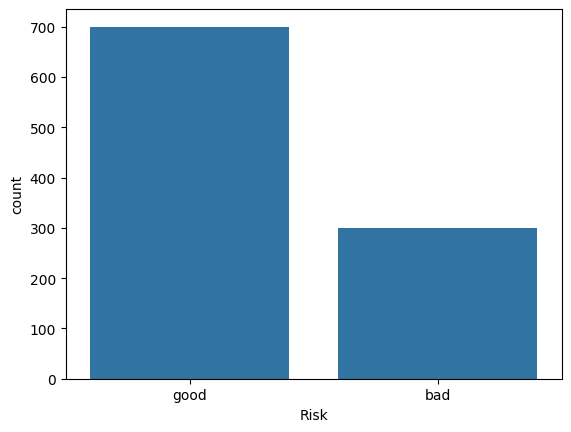

In [36]:
sns.countplot(x='Risk', data=df)
plt.show()

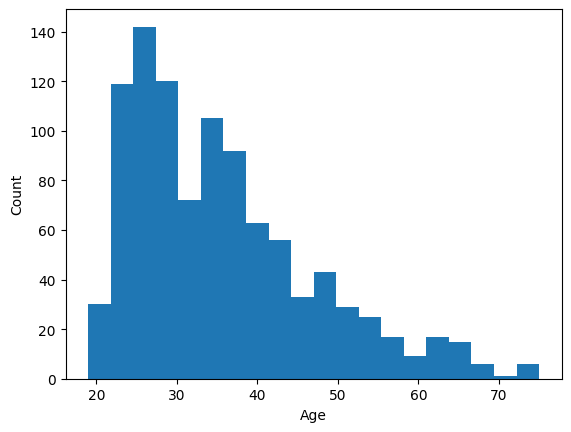

In [37]:
plt.hist(df['Age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [38]:
df['Saving accounts'] = df['Saving accounts'].fillna('Unknown')
df['Checking account'] = df['Checking account'].fillna('Unknown')

df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [39]:
df['Risk'] = df['Risk'].map({
    'good': 0,
    'bad': 1
})

In [40]:
df['Risk'].head()

0    0
1    1
2    0
3    0
4    1
Name: Risk, dtype: int64

In [41]:
df.select_dtypes(include='object').columns

C:\Users\Pranav Parab\AppData\Local\Temp\ipykernel_14292\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='str')

In [42]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Job,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,...,Checking account_little,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,0,True,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,1,False,True,False,True,False,...,False,True,False,False,False,False,False,True,False,False
2,49,1,2096,12,0,True,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,45,2,7882,42,0,True,False,False,True,False,...,True,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,1,True,False,False,True,False,...,True,False,False,True,False,False,False,False,False,False


In [43]:
X = df.drop('Risk', axis=1)
y = df['Risk']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
print(X_train.shape)
print(X_test.shape)

(800, 21)
(200, 21)


STANDARD SCALER & TRAINING ""

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

LOGISTIC REGRESSION


In [47]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

DECISION TREE


In [48]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state = 42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

RANDOM FOREST


In [49]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
     max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
print(rf_predictions[:10])

[0 0 0 0 0 1 0 1 0 0]


EVALUATION OF THE MODEL 


In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [51]:
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall:", recall_score(y_test, lr_predictions))
print("F1 Score:", f1_score(y_test, lr_predictions))

Logistic Regression
Accuracy: 0.755
Precision: 0.631578947368421
Recall: 0.4067796610169492
F1 Score: 0.4948453608247423


In [52]:
print("DecisionTreeClassifier")

print("Accuracy:", accuracy_score(y_test, dt_predictions))
print("Precision:", precision_score(y_test, dt_predictions))
print("Recall:", recall_score(y_test, dt_predictions))
print("F1 Score:", f1_score(y_test, dt_predictions))

DecisionTreeClassifier
Accuracy: 0.675
Precision: 0.453125
Recall: 0.4915254237288136
F1 Score: 0.4715447154471545


In [53]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall:", recall_score(y_test, rf_predictions))
print("F1 Score:", f1_score(y_test, rf_predictions))

Random Forest
Accuracy: 0.755
Precision: 0.6666666666666666
Recall: 0.3389830508474576
F1 Score: 0.449438202247191
